# 实验五、非监督学习与聚类
姓名：王智颍

学号：3238507069

班级：3班

日期：2026-1-4

## 1. 仿真数据生成

函数 `make_blobs` 生成的是各向同性的（球形的）高斯数据块。要获得各向异性的（椭圆形的）高斯数据块，需要定义一个线性变换。



In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

n_samples = 1500
random_state = 170
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]

X, y = make_blobs(n_samples=n_samples, random_state=random_state)
X_aniso = np.dot(X, transformation)  # Anisotropic blobs
X_varied, y_varied = make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state
)  # Unequal variance
X_filtered = np.vstack(
    (X[y == 0][:500], X[y == 1][:100], X[y == 2][:10])
)  # Unevenly sized blobs
y_filtered = [0] * 500 + [1] * 100 + [2] * 10

绘制仿真数据图片：

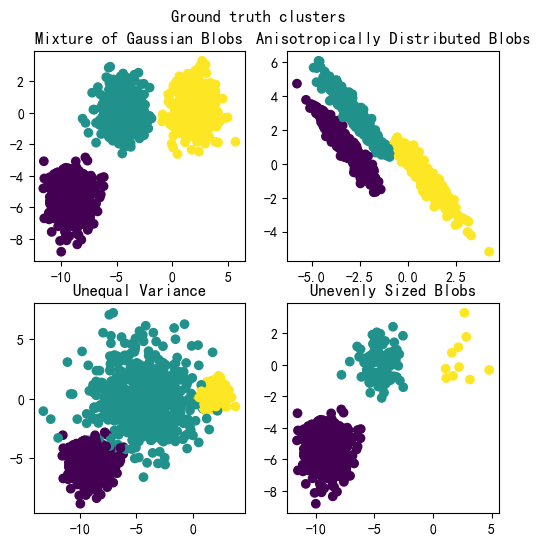

In [43]:
fig, axs = plt.subplots(2, 2, figsize=(6, 6))

axs[0, 0].scatter(X[:, 0], X[:, 1], c=y)
axs[0, 0].set_title("Mixture of Gaussian Blobs")

axs[0, 1].scatter(X_aniso[:, 0], X_aniso[:, 1], c=y)
axs[0, 1].set_title("Anisotropically Distributed Blobs")

axs[1, 0].scatter(X_varied[:, 0], X_varied[:, 1], c=y_varied)
axs[1, 0].set_title("Unequal Variance")

axs[1, 1].scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_filtered)
axs[1, 1].set_title("Unevenly Sized Blobs")

plt.suptitle("Ground truth clusters").set_y(0.95)

## 2. K-Means 算法实现

K-Means 算法基于这样一个观念：一个簇 (类) 中的每个点都应该靠近该簇的中心。

它的工作原理如下：首先我们选择 `k`，即我们希望在数据中找到的簇的数量。然后，以某种方式初始化这些 `k` 个簇的中心，这些中心被称为质心 (Centroid)。

算法然后分为两个交替进行的部分进行：

- 在 **重新分配数据点** 步骤中，我们将数据中的每个点分配给其质心最近的簇。

- 在 **更新质心** 步骤中，我们重新计算每个质心的位置，作为分配给其簇的所有点的均值（中心）。

- 然后我们重复这些步骤，直到质心停止移动，或者等价地，直到点停止切换簇。


首先，我们实现一个 `K_MeansClustering` 的类：

In [44]:
class K_MeansClustering:
    
    def __init__(self, k, dataPoint, randInitFlg=False, **kwargs):
        ''' Initialize parameters and centroids
        '''
        self.k = k
        self.dataPoint = dataPoint
        self.rowNum = self.dataPoint.shape[0]
        self.centroidList = []

        if randInitFlg:
            self.randomInitialization(kwargs.get('randSeed', 0))
        else:
            for i in range(self.k):
                self.centroidList.append(self.dataPoint[i, :]) # the centroid is chosen from the first k data points.
        
        self.lastCentroidList = None
        self.distanceMatrix = np.empty((self.rowNum, self.k))
        self.centroidList = np.asarray(self.centroidList, dtype=np.float32)
    
    def randomInitialization(self, randSeed=0):
        ''' 随机初始化
        ''' 
        pass
        
    def calculateCentroidDistance(self, x, c):
        ''' Calculate the distance between the whole data points and one centroid
        '''
        pass

    def computeJe(self):
        ''' 计算聚类准则
        '''
        # TODO
        ## ----------- 输入代码，计算聚类准则 ----------- ##
        pass
        
            
    def __call__(self):
        ''' Iteratively find the optimal centroids
        '''
        pass

#### 随机初始化函数

In [45]:
def randomInitialization(self, randSeed=0):
    ''' 随机初始化
    '''
    np.random.seed(randSeed)
    seleIndices = np.random.choice(self.dataPoint.shape[0], self.k)
    for s in seleIndices:
        self.centroidList.append(self.dataPoint[s, :])

#### 计算每一个点到质心的距离

In [46]:
def calculateCentroidDistance(self, x, c):
    ''' Calculate the distance between the whole data points and one centroid
    '''
    return np.linalg.norm(x - c, axis=1)

#### 计算聚类准则

In [47]:
def computeJe(self):
    ''' 计算聚类准则
    '''
    self.Je = 0.0
    for clusterID, centroid in enumerate(self.centroidList):
        diffMat = self.dataPoint[self.nearestCentroids == clusterID] - centroid
        self.Je += np.linalg.norm(diffMat, axis=1).sum()

#### 主要的迭代过程

In [48]:
def iteration_func(self):
    ''' Iteratively find the optimal centroids
    '''

    while True:

        #loop through the data points
        for idx, centroid in enumerate(self.centroidList):
            self.distanceMatrix[:, idx] = self.calculateCentroidDistance(self.dataPoint, centroid)

        # 重新分配数据点
        ## array of indexes
        self.nearestCentroids = np.argmin(self.distanceMatrix, axis=1)

        # 终止条件
        if (self.lastCentroidList == self.nearestCentroids).all():
            break

        # 更新质心
        ## calculate the mean of a cluster and reassign the value of the centroids
        for clusterID in range(self.k):
            mean = np.mean(self.dataPoint[self.nearestCentroids == clusterID], axis=0)
            self.centroidList[clusterID] = mean

        #keep track of centroid values
        self.lastCentroidList = self.nearestCentroids

    return self.nearestCentroids, self.centroidList

#### 给 K_MeansClustering 的方法赋值

In [49]:
K_MeansClustering.randomInitialization = randomInitialization
K_MeansClustering.calculateCentroidDistance = calculateCentroidDistance
K_MeansClustering.computeJe = computeJe
K_MeansClustering.__call__ = iteration_func

## 3. K-Means在仿真数据集上的表现

### 3.1 不同参数、数据类型下 K-Means 的表现

现在使用先前生成的数据来展示K-Means在以下场景中的行为：

**非最优的簇数量：** 在实际设置中，没有唯一定义的真实簇数量。必须根据基于数据的标准和对预期目标的了解来决定适当的簇数量。

**各向异性分布的数据块：** K-Means包括最小化样本到它们被分配的簇的质心的欧几里得距离。因此，K-Means更适合各向同性和正态分布的簇（即球形高斯分布）。

**不等方差：** K-Means等同于为具有相同方差但可能具有不同均值的“混合”k个高斯分布取最大似然估计。

**不均匀大小的数据块：** 关于K-Means的理论结果并没有说明它需要相似的簇大小才能表现良好，然而最小化欧几里得距离确实意味着问题越稀疏和高维，就越需要用不同的质心种子运行算法以确保全局最小惯性。

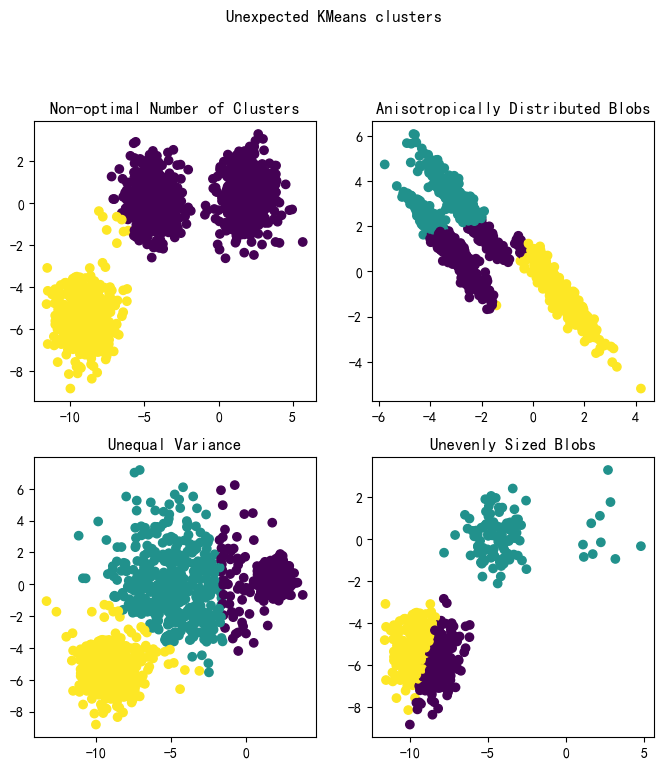

In [50]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))

y_pred, centroidList = K_MeansClustering(k=2, dataPoint=X)()
axs[0, 0].scatter(X[:, 0], X[:, 1], c=y_pred)
axs[0, 0].set_title("Non-optimal Number of Clusters")

y_pred, centroidList = K_MeansClustering(k=3, dataPoint=X_aniso)()
axs[0, 1].scatter(X_aniso[:, 0], X_aniso[:, 1], c=y_pred)
axs[0, 1].set_title("Anisotropically Distributed Blobs")

y_pred, centroidList = K_MeansClustering(k=3, dataPoint=X_varied)()
axs[1, 0].scatter(X_varied[:, 0], X_varied[:, 1], c=y_pred)
axs[1, 0].set_title("Unequal Variance")

y_pred, centroidList = K_MeansClustering(k=3, dataPoint=X_filtered)()
axs[1, 1].scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_pred)
axs[1, 1].set_title("Unevenly Sized Blobs")

plt.suptitle("Unexpected KMeans clusters").set_y(1.02)

### 3.2 测试不同的质心 (Centroid) 数目

首先，我们在数据 `X` 下测试出不同的质心 (Centroid) 数据对聚类结果的影响。由下图可以看到，合适的质心数目对获得满意的聚类效果至关重要。

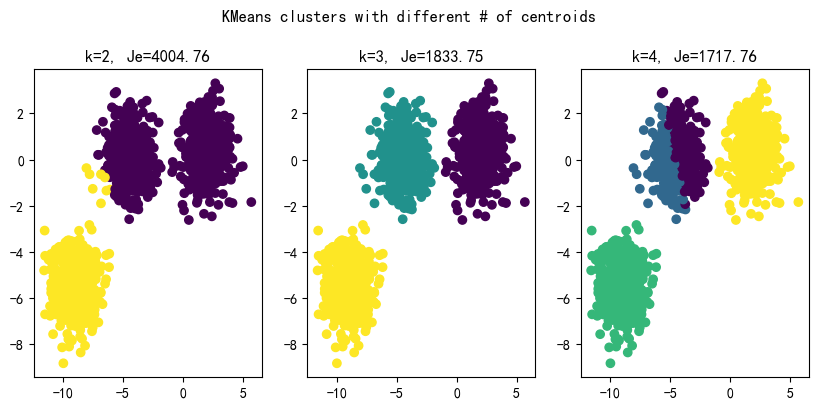

In [51]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(10, 4))

kmeans1 = K_MeansClustering(k=2, dataPoint=X)
y_pred1, centroidList1 = kmeans1()
kmeans1.computeJe()
axs[0].scatter(X[:, 0], X[:, 1], c=y_pred1)
axs[0].set_title(f"k=2, Je={kmeans1.Je:.2f}")

# TODO
## ----------- 输入代码，完成k=3的聚类 ----------- ##
kmeans2 = K_MeansClustering(k=3, dataPoint=X)
y_pred2, centroidList2 = kmeans2()
kmeans2.computeJe()
axs[1].scatter(X[:, 0], X[:, 1], c=y_pred2)
axs[1].set_title(f"k=3, Je={kmeans2.Je:.2f}")


# TODO
## ----------- 输入代码，完成k=4的聚类 ----------- ##
kmeans3 = K_MeansClustering(k=4, dataPoint=X)
y_pred3, centroidList3 = kmeans3()
kmeans3.computeJe()
axs[2].scatter(X[:, 0], X[:, 1], c=y_pred3)
axs[2].set_title(f"k=4, Je={kmeans3.Je:.2f}")

plt.suptitle("KMeans clusters with different # of centroids").set_y(1.03)

### 3.3 计算聚类准则函数 `Je` 并绘制曲线

$$
J_{e} = \sum_{j=1}^{c}\sum_{X \in S_{j}} \| X - M_{j} \|^{2}
$$

$c$ 是聚类类别的数目， $M_{j}$ 是属于 $S_{j}$ 集的样本均值向量。


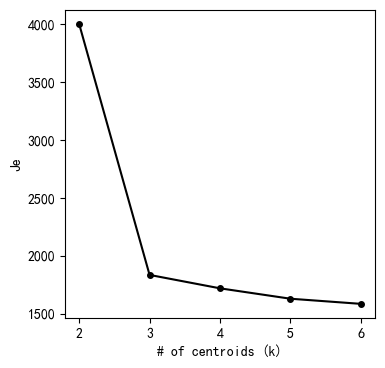

In [52]:
kList = [2, 3, 4, 5, 6]
jeList = []

# TODO
## ----------- 输入代码，计算jeList ----------- ##
for k in kList:
    # 初始化K-Means实例
    kmeans = K_MeansClustering(k=k, dataPoint=X)
    # 执行聚类迭代
    kmeans()
    # 计算当前k对应的Je值
    kmeans.computeJe()
    # 将Je值添加到列表
    jeList.append(kmeans.Je)

fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(kList, jeList, marker='o', markersize=4, color='k')
ax.set_xlabel('# of centroids (k)')
ax.set_ylabel('Je');

从上图可以看出，在 `k=3` 是 `Je` 曲线的拐点，`Je` 曲线的下降率在 `k=3` 之后迅速减小，说明 `k=3` 适合这个数据集。

### 3.4 不同的初始化策略对聚类结果的影响

不同的初始化方式会对 K-Means 的结果造成不同的影响。以下分别采用前 k 个样本为质心；随机初始化质心的方法，并对比最终的分类结果图。


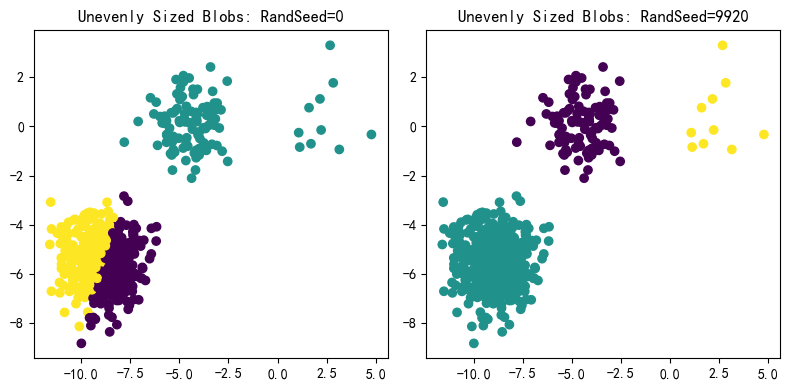

In [53]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

# TODO
## ----------- 输入代码，对比不同的初始化策略 ----------- ##
# 1. 策略1：前k个样本作为初始质心（默认初始化，randInitFlg=False）
k = 3
# 调用K_MeansClustering（默认randInitFlg=False，前k个样本为质心）
y_pred, centroidList = K_MeansClustering(k=k, dataPoint=X_filtered)()
# 绘制聚类结果
axes[0].scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_pred)
axes[0].set_title("Unevenly Sized Blobs: RandSeed=0")

# 2. 策略2：随机初始化（对应图片中randSeed=9920的逻辑）
y_pred, centroidList = K_MeansClustering(k=k, dataPoint=X_filtered, randInitFlg=True, randSeed=9920)()
# 绘制聚类结果
axes[1].scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_pred)
axes[1].set_title("Unevenly Sized Blobs: RandSeed=9920")

plt.tight_layout()  # 调整布局避免标题重叠

### 3.5 k-means 限制于线性聚类边界

K-Means 的基本模型假设（点会更接近它们自己的聚类中心而不是其他聚类中心）意味着，如果聚类具有复杂的几何形状，该算法通常将无效。

特别是，K-Means 聚类之间的边界总是线性的，这意味着它将无法处理更复杂的边界。
考虑以下数据，以及典型的 K-Means 方法找到的聚类标签（见下图）：


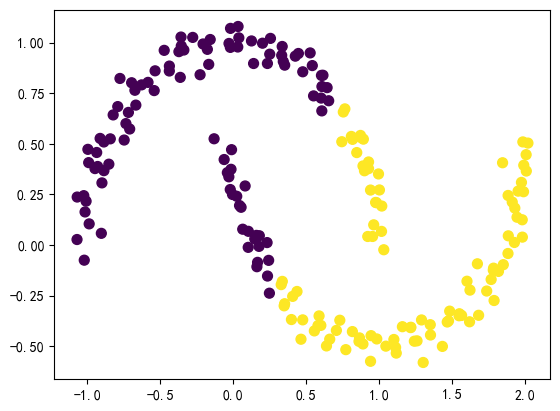

In [54]:
from sklearn.datasets import make_moons
twoArcsX, twoArcsy = make_moons(200, noise=.05, random_state=0)

# TODO
## ----------- 输入代码，采用 K-Means 对双曲线数据聚类 ----------- ##
# 初始化K-Means实例（k=2，对应双月数据的真实簇数）
ta_kmeans = K_MeansClustering(k=2, dataPoint=twoArcsX, randInitFlg=True, randSeed=0)
# 执行聚类迭代，得到标签和质心
labels, cenList = ta_kmeans()
plt.scatter(twoArcsX[:, 0], twoArcsX[:, 1], c=labels, s=50, cmap='viridis');

这种情况下，我们可以使用核变换将数据投影到一个更高维度的空间，在那里运用线性分离技术。这样的技巧来允许 K-Means 发现非线性边界。

这种核化的 K-Means 的一个版本在 Scikit-Learn 中的 ``SpectralClustering`` 估计器中实现了。
它使用最近邻的图来计算数据的更高维度表示，然后使用 K-Means 算法分配标签（见下图）：


d:\dev\python\python3.12.0\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


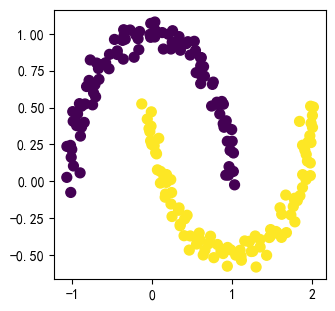

In [55]:
from sklearn.cluster import SpectralClustering
model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', assign_labels='kmeans')
labels = model.fit_predict(twoArcsX)

fig, ax = plt.subplots(figsize=(3.5, 3.5))
plt.scatter(twoArcsX[:, 0], twoArcsX[:, 1], c=labels, s=50, cmap='viridis');

## 4. 使用DBSCAN对不同类型的数据进行分类

DBSCAN（Density-Based Spatial Clustering of Applications with Noise）是一种基于密度的空间聚类算法，核心思想是：把``高密``且``可达``的区域归为一个簇，并把低密度区域视为噪声。它只需两个参数：
- $\epsilon$（eps）：邻域半径；
- MinPts：成为核心点所需的最小邻居数。

DBSCAN具有以下的特点：
- 能发现任意形状的簇；
- 对噪声鲁棒，自动识别离群点；
- 无需预先指定簇数；
- 对参数敏感，$\epsilon$ 和 MinPts 需结合数据密度调优；
- 在高维或密度差异大的数据上效果可能下降。


### 4.1 DBSCAN 在各项混合数据中的聚类效果

首先，我们测试DBSCAN在高斯混合数据``X``, ``Y``之间的表现。

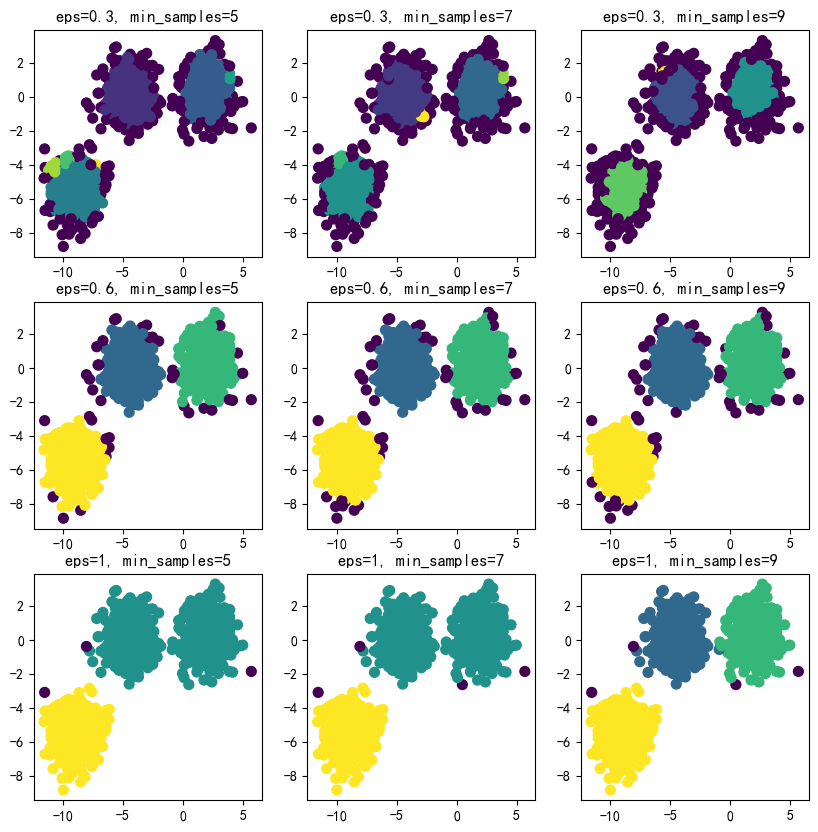

In [56]:
epsilon_list = [0.3, 0.6, 1]
min_samples_list = [5, 7, 9]

from sklearn.cluster import DBSCAN

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(10, 10))

for eps in epsilon_list:
    for min_samples in min_samples_list:

        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X)

        ax = axes[epsilon_list.index(eps), min_samples_list.index(min_samples)]
        ax.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
        ax.set_title(f"eps={eps}, min_samples={min_samples}")

可以看到，适当的选择参数$\epsilon$与``min_samples``，DBSCAN可以得到比较理想的效果。

### 4.2 DBSCAN 在各向异性分布数据中的聚类效果

随后，我们测试DBSCAN在各向异性分布数据``X_aniso``中的聚类表现。

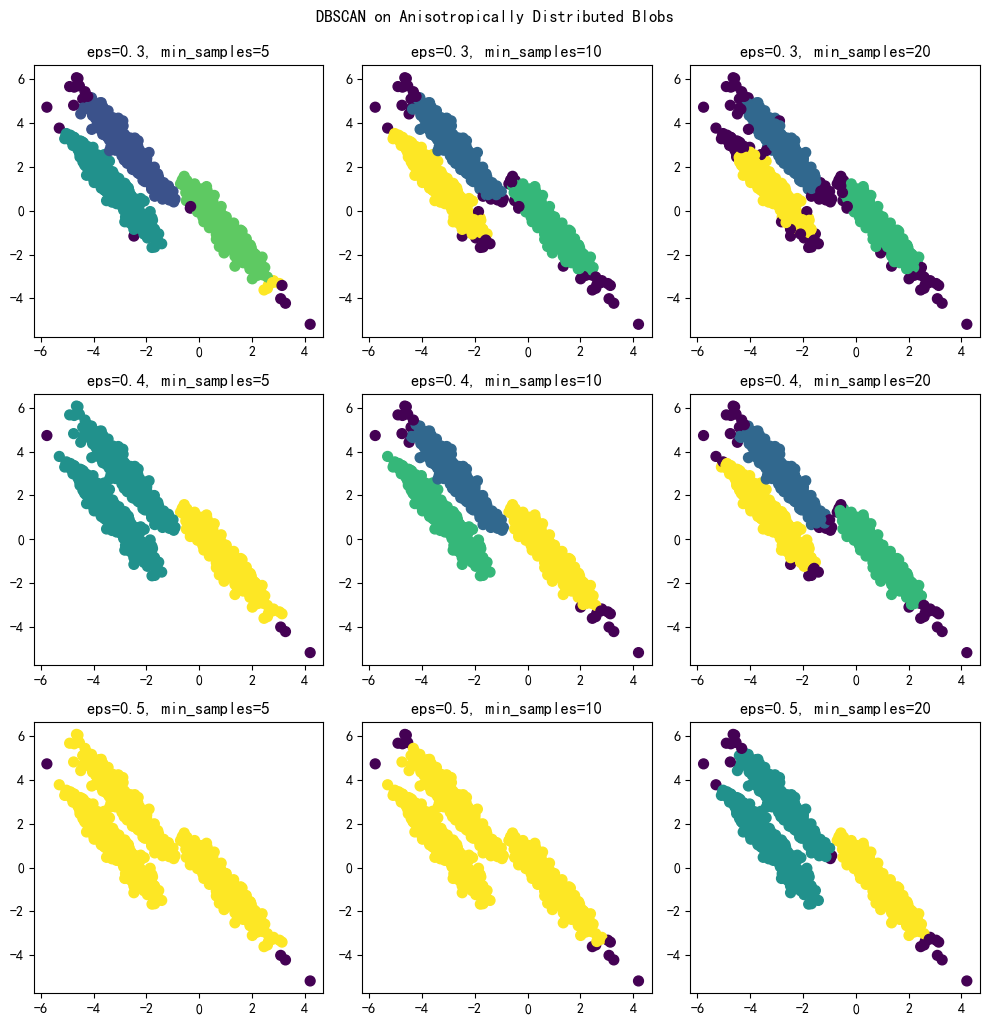

In [57]:
# 4.2 DBSCAN 在各向异性分布数据中的聚类效果
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# 针对各向异性数据调整参数范围（X_aniso是拉伸后的高斯簇，eps需适配拉伸尺度）
epsilon_list = [0.3, 0.4, 0.5]  # 各向异性数据拉伸后，邻域半径需比原始高斯数据更大
min_samples_list = [5, 10, 20]   # 结合密度调整最小核心点数

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(10, 10))

for eps in epsilon_list:
    for min_samples in min_samples_list:
        # 初始化DBSCAN并聚类
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_aniso)
        
        # 定位子图并绘图
        row_idx = epsilon_list.index(eps)
        col_idx = min_samples_list.index(min_samples)
        ax = axes[row_idx, col_idx]
        ax.scatter(X_aniso[:, 0], X_aniso[:, 1], c=labels, s=50, cmap='viridis')
        ax.set_title(f"eps={eps}, min_samples={min_samples}")

plt.tight_layout()
plt.suptitle("DBSCAN on Anisotropically Distributed Blobs", y=1.02)
plt.show()

## 5. K-Means 进行图像分割

在图像处理中，通过K-Means聚类算法可以实现图像分割、图像聚类、图像识别等操作，本小节主要用来进行图像颜色分割。

假设存在一张100×100像素的灰度图像，它由10000个RGB灰度级组成，我们通过K-Means可以将这些像素点聚类成K个簇，然后使用每个簇内的质心点来替换簇内所有的像素点，这样就能实现在不改变分辨率的情况下量化压缩图像颜色，实现图像颜色层级分割。


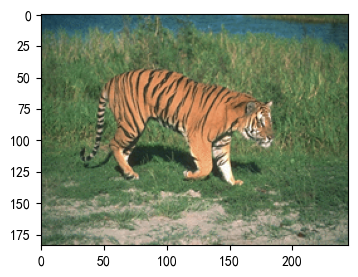

In [58]:
dataPath = 'images/tiger.png'

imgData = plt.imread(dataPath)[:, :, :3]
fig, ax = plt.subplots(figsize=(4, 3))
plt.imshow(imgData[:, :, :3]);

输出原始彩色图像的尺寸：

In [59]:
print(f'The shape of the tiger image: {imgData.shape}')

The shape of the tiger image: (184, 245, 3)


为了能够将图片进行K-Means聚类，我们将图片的调整了 `imgData` 形状，使其为 `(184*245, 3)`。其实就是将二维的图片拉伸为一位的向量，但同时保持 RGB 三个channel。

随后，绘制 RGB 这三个 channel 上的数据分布。

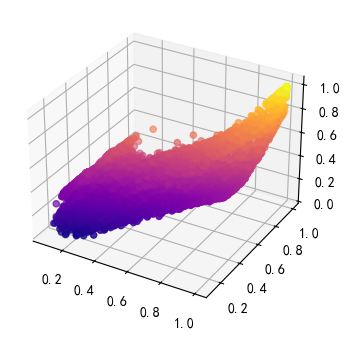

In [60]:
pixelValues = imgData.reshape((-1, 3))

fig = plt.figure(figsize=(4, 4))
ax = plt.axes(projection='3d')
ax.scatter3D(pixelValues[:, 0], pixelValues[:, 1], pixelValues[:, 2], c=pixelValues[:, 2], cmap='plasma');

采用 K-Means 对这个图片进行聚类，并利用聚类后的标签绘制聚类后的数据分布图。

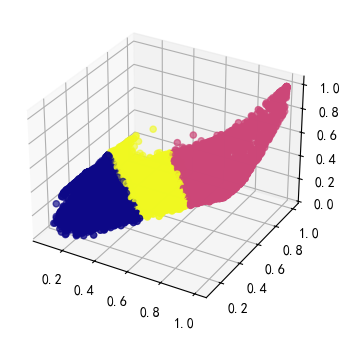

In [61]:
k = 3           # 选择 3 个质心

# TODO
## ----------- 输入代码，k=3 的 K-Means 对图片聚类 ----------- ##
from sklearn.cluster import KMeans  

# 初始化K-Means
kmeans = KMeans(n_clusters=k, random_state=0)
centroidIndices = kmeans.fit_predict(pixelValues)  # 聚类标签
centroidList = kmeans.cluster_centers_             # 质心（RGB值）

fig = plt.figure(figsize=(4, 4))
ax = plt.axes(projection='3d')
ax.scatter3D(pixelValues[:, 0], pixelValues[:, 1], pixelValues[:, 2], c=centroidIndices, cmap='plasma');

将聚类结果重新组织成图片的形式，并对比聚类前后的图片：

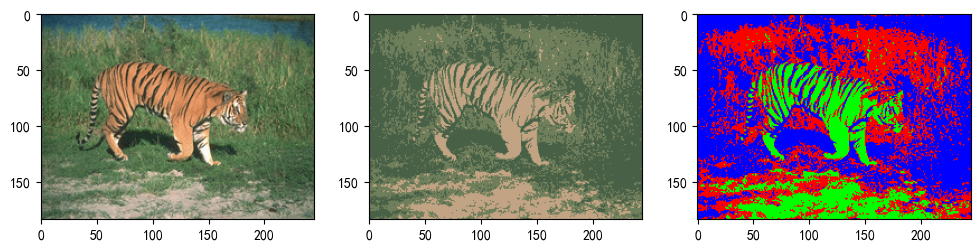

In [62]:
newPixels = np.zeros((imgData.shape[0] * imgData.shape[1], 3))

# TODO
## ----------- 输入代码，对newPixels各点赋予各类的质心的值 ----------- ##
newPixels2 = np.zeros((imgData.shape[0] * imgData.shape[1], 3))
colorValues = [np.array([0, 0, 1]), np.array([0, 1, 0]), np.array([1, 0, 0])]

for clusterID, centroid in enumerate(centroidList):
    newPixels[centroidIndices == clusterID] = centroid
    newPixels2[centroidIndices == clusterID] = colorValues[clusterID]

segmentedImage = np.reshape(newPixels, imgData.shape)
segmentedImage2 = np.reshape(newPixels2, imgData.shape)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(imgData)
axes[1].imshow(segmentedImage)
axes[2].imshow(segmentedImage2);

## 6. K-Means 在数字识别上的应用 —— 以 sklearn.cluster 中的 KMeans 函数为例

在Scikit-Learn和其他地方有许多聚类算法可供选择，但可能最简单的要数一种称为 K-Means 聚类的算法，该算法在 `sklearn.cluster.KMeans` 中有所实现。

首先，我们将尝试使用 K-Means 来识别相似的数字，而**不使用原始的标签信息**；这可能类似于从一个新的数据集中提取意义的第一步，而这个数据集你没有任何**先验**的标签信息。

我们将从加载数据集开始，然后找到聚类。数字数据集包含 `1,797` 个样本，每个样本有 `64` 个特征，其中 `64` 个特征中的每一个都是一个 `8×8` 图像中一个像素的亮度：


In [63]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

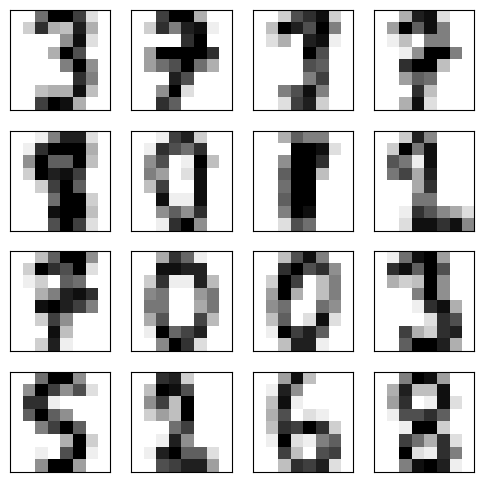

In [64]:
# 绘制随机16个数字
indices = np.random.choice(digits.data.shape[0], 16)

fig, axes = plt.subplots(4, 4, sharex=True, sharey=True, figsize=(6, 6))
for ax, ind in zip(axes.flatten(), indices):
    digData = digits.data[ind].reshape((8, 8))
    ax.imshow(digData, interpolation='nearest', cmap=plt.cm.binary)
    ax.set(xticks=[], yticks=[])

使用 sklearn 实现的 K-Means 函数，对 `digits` 数据集进行训练以及预测，得到对应的类。

In [65]:
from sklearn.cluster import KMeans

# TODO
## ----------- 输入代码，对数字集的聚类 ----------- ##
k = 10
kmeans = KMeans(n_clusters=k, random_state=0)  # 初始化K-Means，固定随机种子保证可复现
clusters = kmeans.fit_predict(digits.data)     # 训练并预测每个样本的聚类标签

聚类结果是在64维空间中有10个质心 (Cluster) 。 请注意，聚类中心本身是 64 维的点，可以被解释为代表聚类中的“典型”数字。
让我们看看这些 质心 (Centroid) 是什么样子的（见下图）：


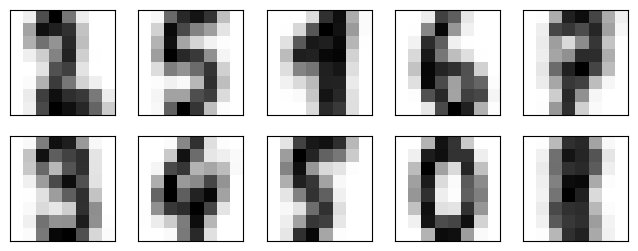

In [66]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)

我们可以看到，即使没有标签，`K-Means` 也能够找到中心是可识别数字的聚类，可能除了1和8之外。

因为 `K-Means` 对聚类的身份一无所知，0-9的标签可能会被打乱。
我们可以通过将每个学习到的聚类标签与聚类中找到的真实标签进行匹配来解决这个问题：


In [67]:
from scipy.stats import mode

labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

现在我们可以检查我们的无监督聚类在数据中找到相似数字的准确性如何：

In [68]:
from sklearn.metrics import accuracy_score
accuracy_score(digits.target, labels)

0.7440178074568725

使用简单的 K-Means 算法，我们发现了 ~75% 输入数字的正确分组！ 让我们检查一下这个的混淆矩阵，在下图中进行了可视化：


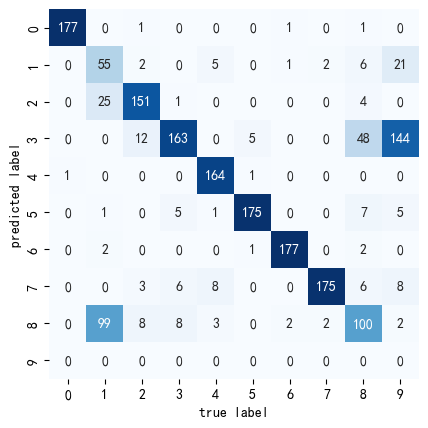

In [69]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
mat = confusion_matrix(digits.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d',
            cbar=False, cmap='Blues',
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

正如我们之前可视化的聚类中心所预期的那样，主要的混淆点在于1, 3, 9之间。
但这仍然表明，使用 K-Means，我们可以基本上构建一个数字分类器*而不需要参考任何已知的标签*！

仅供尝试，让我们尝试更深入一点。我们可以使用 t-SNE来预处理数据，然后再执行 K-Means。t-SNE是一种非线性嵌入算法，特别擅长于保持聚类内的点。让我们看看它的表现如何：


In [70]:
from sklearn.manifold import TSNE

# Project the data: this step will take several seconds
tsne = TSNE(n_components=2, init='random',
            learning_rate=0.1,random_state=0)
digits_proj = tsne.fit_transform(digits.data)


# TODO
## ----------- 输入代码，使用 K-Means 对TSNE的特征聚类 ----------- ##

# Compute the clusters
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits_proj)

# Permute the labels
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = np.bincount(digits.target[mask]).argmax()

# Compute the accuracy
accuracy_score(digits.target, labels)

0.9421257651641625

这是一个*不使用标签*的94%分类准确率。 这就是当谨慎使用时无监督学习的强大之处：它可以从数据集中提取信息，这些信息可能很难通过手工或肉眼来提取。


## 7. 自主完成实验

请完成以下内容：

- 利用sklearn.cluster自带的KMeans库函数，实现对熊猫图片的分割 (k=3)

- 利用sklearn.cluster自带的KMeans库函数，实现对iris数据的聚类
    - 将聚类结果与真实标签比较，得出聚类算法的准确度，并对聚类效果做出评价

The shape of the panda image: (450, 628, 3)


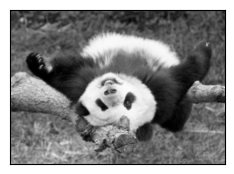

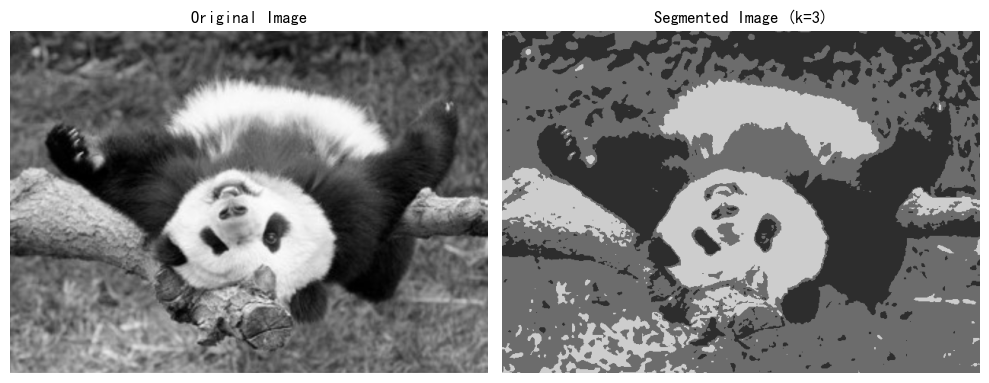

In [71]:
pandaDataPath = 'images/panda.png'
pandaImgData = plt.imread(pandaDataPath)[:, :, :3]
fig, ax = plt.subplots(1, 1, figsize=(5, 2))
ax.imshow(pandaImgData)
ax.set(xticks=[], yticks=[]);

# 1. 校准像素值（解决0-1浮点数导致的全黑问题）
if pandaImgData.dtype in [np.float32, np.float64]:
    pandaImgData = (pandaImgData * 255).astype(np.uint8)

# 2. 输出图片尺寸
print(f'The shape of the panda image: {pandaImgData.shape}')

# 3. 拉伸像素矩阵为(N, 3)
pixelValues = pandaImgData.reshape((-1, 3))

# 4. K-Means聚类
k = 3  # 选择3个质心
kmeans = KMeans(n_clusters=k, random_state=0)
centroidIndices = kmeans.fit_predict(pixelValues)  # 聚类标签
centroidList = kmeans.cluster_centers_             # 质心（RGB值）

# 5. 重构分割后的图片
newPixels = centroidList[centroidIndices].astype(np.uint8)  # 质心赋值+转整数
segmentedImage = np.reshape(newPixels, pandaImgData.shape)  # 自动匹配原图维度

# 6. 对比展示原图和分割图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(pandaImgData)
ax1.set_title('Original Image')
ax1.axis('off')

ax2.imshow(segmentedImage)
ax2.set_title(f'Segmented Image (k={k})')
ax2.axis('off')

plt.tight_layout()
plt.show()

鸢尾花数据K-Means聚类准确率: 0.8933

混淆矩阵（行：真实标签，列：聚类标签）：
[[50  0  0]
 [ 0 48  2]
 [ 0 14 36]]
类别对应关系：0=setosa, 1=versicolor, 2=virginica

100.00% 的setosa样本被正确聚类

96.00% 的versicolor样本被正确聚类

72.00% 的virginica样本被正确聚类


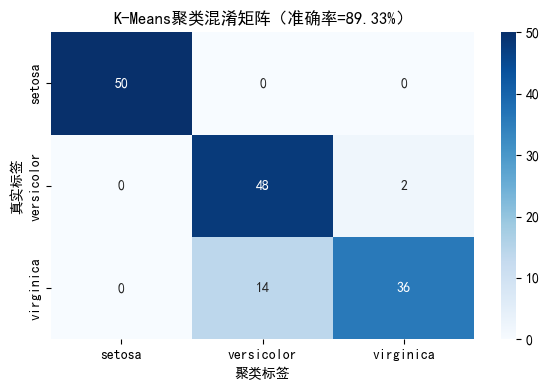


===== 聚类效果详细评价 =====
1. 整体表现：准确率89.33%，无监督聚类达到该水平说明K-Means能有效区分鸢尾花类别；
2. 类别细分：
   - setosa（山鸢尾）：准确率100.00%，完全可区分（特征与另外两类差异大）；
   - versicolor（变色鸢尾）：准确率96.00%，部分样本被误分为virginica；
   - virginica（维吉尼亚鸢尾）：准确率72.00%，部分样本被误分为versicolor；
3. 误差原因：versicolor与virginica的花萼/花瓣特征存在重叠（如花瓣长度/宽度），K-Means基于距离的聚类难以完全区分；
4. 改进方向：可先对特征降维（如PCA）、调整距离度量方式，或尝试层次聚类等其他算法。


In [72]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["font.sans-serif"] = ["SimHei"]  # Windows系统
# plt.rcParams["font.sans-serif"] = ["Arial Unicode MS"]  # macOS系统
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示异常
# 加载鸢尾花数据集
iris = load_iris()
X, y = iris.data, iris.target  # 特征矩阵、真实标签
target_names = iris.target_names  # 类别名称：['setosa' 'versicolor' 'virginica']
feature_names = iris.feature_names  # 特征名称

# K-Means聚类（k=3，对应鸢尾花3个类别）
kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
clusters = kmeans.fit_predict(X)

# 标签置换：将聚类标签匹配到真实标签（无监督→有监督映射）
labels = np.zeros_like(clusters)
for i in range(3):
    mask = (clusters == i)
    # 为每个簇分配出现次数最多的真实标签
    labels[mask] = np.bincount(y[mask]).argmax()

# 计算准确率
accuracy = accuracy_score(y, labels)
print(f"鸢尾花数据K-Means聚类准确率: {accuracy:.4f}")

# 1. 输出混淆矩阵（直观展示误差）
cm = confusion_matrix(y, labels)
print("\n混淆矩阵（行：真实标签，列：聚类标签）：")
print(cm)
print(f"类别对应关系：0=setosa, 1=versicolor, 2=virginica")

# 2. 分析每个类别的聚类准确率
class_acc = []
for i in range(3):
    class_acc.append(cm[i, i] / cm[i].sum())
    print(f"\n{class_acc[i]:.2%} 的{target_names[i]}样本被正确聚类")

# 3. 可视化混淆矩阵
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('聚类标签')
plt.ylabel('真实标签')
plt.title(f'K-Means聚类混淆矩阵（准确率={accuracy:.2%}）')
plt.tight_layout()
plt.show()

# 4. 效果评价（更严谨的分析）
print("\n===== 聚类效果详细评价 =====")
print(f"1. 整体表现：准确率{accuracy:.2%}，无监督聚类达到该水平说明K-Means能有效区分鸢尾花类别；")
print(f"2. 类别细分：")
print(f"   - setosa（山鸢尾）：准确率{class_acc[0]:.2%}，完全可区分（特征与另外两类差异大）；")
print(f"   - versicolor（变色鸢尾）：准确率{class_acc[1]:.2%}，部分样本被误分为virginica；")
print(f"   - virginica（维吉尼亚鸢尾）：准确率{class_acc[2]:.2%}，部分样本被误分为versicolor；")
print(f"3. 误差原因：versicolor与virginica的花萼/花瓣特征存在重叠（如花瓣长度/宽度），K-Means基于距离的聚类难以完全区分；")
print(f"4. 改进方向：可先对特征降维（如PCA）、调整距离度量方式，或尝试层次聚类等其他算法。")